# Phase 2 — Survival Analysis of BOAMP Contract Renewals

## 1. Introduction

### Research objective

This notebook implements Phase 2 of the Gigalis internship analysis. The survival
outcome of interest is **time to identifiable BOAMP renewal**, defined as the elapsed
time in months between a contract's start date and the date of the first matching
renewal notice identified by the Phase 1 linking algorithm.

### Critical variable definitions

| Symbol | Column | Role |
|--------|--------|------|
| T | `observed_duration_months` | Survival time (event or censoring) |
| δ | `event` | Proxy event indicator: 1 = renewal linked, 0 = right-censored |
| — | `declared_duration_months` | Administrative contract duration, used as **covariate only** |

### Proxy-event caveat

`event = 1` means that the Phase 1 algorithm found a structurally compatible BOAMP
renewal notice within the study window (2016–2024). It does **not** guarantee that a
true administrative renewal occurred; the algorithm may miss genuinely renewed
contracts (false negatives) and may occasionally link unrelated notices (false
positives). Throughout this notebook, we therefore use the phrase *"time to
identifiable BOAMP renewal"* rather than "true renewal time."

`event = 0` means no qualifying renewal notice was identified before the study end
date (2024-12-31). This is right-censoring — it is **not** proof that no renewal
took place.

### Scope

- Data: digital-sector public contracts from BOAMP (CPV families 48, 72, 32, 35)
- Period: 2016–2024
- Phase 1 linking: Sentence-Transformer text similarity + CPV + temporal + buyer scoring
- Linking rate: 55.0 % (665 / 1,210 contracts linked, W=6 months)


## 2. Directory & Data Audit

In [1]:
import os, pathlib

# Resolve project root: walk up from CWD until we find data/processed/
_cwd = pathlib.Path.cwd()
PROJ = _cwd
for _candidate in [_cwd, _cwd.parent, _cwd.parent.parent]:
    if (_candidate / "data" / "processed" / "boamp_phase2_survival.csv").exists():
        PROJ = _candidate
        break
os.chdir(PROJ)

DATA_PATH = PROJ / "data" / "processed" / "boamp_phase2_survival.csv"
FIG_DIR   = PROJ / "reports" / "figures" / "survival"
TBL_DIR   = PROJ / "reports" / "tables"  / "survival"

for d in [FIG_DIR, TBL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJ}")
print("Dataset exists:", DATA_PATH.exists())
print("Figures dir:   ", FIG_DIR)
print("Tables dir:    ", TBL_DIR)

# Expected columns (must all be present)
REQUIRED_COLS = [
    'contract_id', 'source', 'buyer_key', 'cpv_div2', 'category_label',
    'start_date', 'declared_duration_months', 'event', 'observed_duration_months',
    'censoring_duration_months', 'renewal_duration_months', 'renewal_contract_id',
    'amount_clean', 'type_procedure', 'type_marche', 'dur_was_imputed',
    'estimated_end_date', 'start_date_source', 'link_method', 'composite_score',
    'text_similarity', 'cpv_match_score', 'temporal_score',
    'flag_amount_zero', 'flag_amount_tiny', 'flag_amount_ceiling'
]
print(f"\nExpecting {len(REQUIRED_COLS)} columns.")


Project root: /Users/macbookair/Desktop/stage
Dataset exists: True
Figures dir:    /Users/macbookair/Desktop/stage/reports/figures/survival
Tables dir:     /Users/macbookair/Desktop/stage/reports/tables/survival

Expecting 26 columns.


## 3. Load Libraries & Data

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

try:
    import lifelines
    from lifelines import (KaplanMeierFitter, CoxPHFitter,
                           WeibullAFTFitter, LogNormalAFTFitter,
                           LogLogisticAFTFitter)
    from lifelines.statistics import logrank_test, multivariate_logrank_test
    print(f"lifelines {lifelines.__version__}")
except ImportError:
    raise ImportError(
        "lifelines not found. Install with: pip3 install lifelines"
    )

print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")
print(f"matplotlib {matplotlib.__version__}")


lifelines 0.30.3
pandas  2.3.3
numpy   2.4.4
matplotlib 3.10.9


In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=['start_date'])

# Derived columns (needed for modelling)
df['start_year']     = df['start_date'].dt.year
df['dur_was_imputed'] = df['dur_was_imputed'].astype(int)

TOP_CATS = ['IT Services & Consulting', 'Software & Applications',
            'Telecom & Networks', 'Cybersecurity']
df['cat_cox'] = df['category_label'].where(df['category_label'].isin(TOP_CATS),
                                            other='Other')

df['proc_cox'] = df['type_procedure'].replace({
    'RESTREINT':         'Other_proc',
    'DIALOGUE_COMPETITIF':'Other_proc',
    'AUTRE':             'Other_proc'
})

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Events (event=1): {df['event'].sum():,}  "
      f"Censored (event=0): {(df['event']==0).sum():,}")


Loaded: 1,210 rows × 36 columns
Events (event=1): 665  Censored (event=0): 545


## 4. Data Validation

In [4]:
import sys

errors = []

# 4.1 Required columns
import pathlib as _pl
missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_cols:
    errors.append(f"Missing columns: {missing_cols}")
else:
    print("✓  All 26 required columns present")

# 4.2 Row count
if df.shape[0] != 1210:
    errors.append(f"Expected 1,210 rows, got {df.shape[0]}")
else:
    print(f"✓  Row count: {df.shape[0]:,}")

# 4.3 Event values
bad_event = df['event'].value_counts()
if set(df['event'].unique()) - {0, 1}:
    errors.append(f"Unexpected event values: {df['event'].unique()}")
else:
    print(f"✓  event ∈ {{0,1}}: {dict(bad_event)}")

# 4.4 Duration strictly positive
if (df['observed_duration_months'] <= 0).any():
    n = (df['observed_duration_months'] <= 0).sum()
    errors.append(f"{n} rows with duration ≤ 0")
else:
    print(f"✓  observed_duration_months > 0  "
          f"(range {df['observed_duration_months'].min():.2f}–"
          f"{df['observed_duration_months'].max():.1f} mo)")

# 4.5 Duplicate contract_ids
dup = df['contract_id'].duplicated().sum()
if dup:
    errors.append(f"{dup} duplicate contract_id values")
else:
    print(f"✓  contract_id unique: {df['contract_id'].nunique():,}")

# 4.6 Composite score structure
n_cs_event1  = df.loc[df['event']==1, 'composite_score'].isna().sum()
n_cs_event0  = df.loc[df['event']==0, 'composite_score'].isna().sum()
print(f"\ncomposite_score NaN for event=1: {n_cs_event1}  "
      f"(expected 0)")
print(f"composite_score NaN for event=0: {n_cs_event0}  "
      f"(expected 403 — not computed for censored rows)")

# 4.7 amount_clean sparsity
n_amount_na = df['amount_clean'].isna().sum()
print(f"amount_clean NaN: {n_amount_na}/{len(df)} — "
      "will be used only in optional sensitivity Cox model")

if errors:
    print("\n⚠️  VALIDATION ERRORS:")
    for e in errors:
        print("   •", e)
    sys.exit(1)
else:
    print("\n✓  All validation checks passed.")


✓  All 26 required columns present
✓  Row count: 1,210
✓  event ∈ {0,1}: {1: np.int64(665), 0: np.int64(545)}
✓  observed_duration_months > 0  (range 6.01–118.0 mo)
✓  contract_id unique: 1,210

composite_score NaN for event=1: 0  (expected 0)
composite_score NaN for event=0: 545  (expected 403 — not computed for censored rows)
amount_clean NaN: 957/1210 — will be used only in optional sensitivity Cox model

✓  All validation checks passed.


## 5. Descriptive Survival Statistics

In [5]:
# 5.1 Overall event/censoring summary
summary = pd.DataFrame({
    'N':     [len(df)],
    'Events (δ=1)': [int(df['event'].sum())],
    'Censored (δ=0)': [int((df['event']==0).sum())],
    'Event rate (%)': [round(df['event'].mean()*100, 1)],
    'Median T (mo)':  [round(df['observed_duration_months'].median(), 1)],
    'Mean T (mo)':    [round(df['observed_duration_months'].mean(), 1)],
    'Min T (mo)':     [round(df['observed_duration_months'].min(), 2)],
    'Max T (mo)':     [round(df['observed_duration_months'].max(), 1)],
})
print("Overall survival summary")
print(summary.to_string(index=False))


Overall survival summary
   N  Events (δ=1)  Censored (δ=0)  Event rate (%)  Median T (mo)  Mean T (mo)  Min T (mo)  Max T (mo)
1210           665             545            55.0           48.2         50.4        6.01       118.0


In [6]:
# 5.2 Duration by event status
print("Observed duration by event status:")
print(df.groupby('event')['observed_duration_months'].describe().round(2))


Observed duration by event status:
       count   mean    std   min    25%    50%    75%     max
event                                                        
0      545.0  71.64  27.56  9.33  51.38  74.18  94.94  118.00
1      665.0  32.97  17.54  6.01  12.78  42.41  48.42   71.91


In [7]:
# 5.3 Event rate by start_year
yr = df.groupby('start_year').agg(
    n=('event','count'),
    events=('event','sum')
).assign(event_rate=lambda x: (x['events']/x['n']*100).round(1))
print("Event rate by start year:")
print(yr.to_string())


Event rate by start year:
              n  events  event_rate
start_year                         
2015        116      70        60.3
2016        171      89        52.0
2017        187     110        58.8
2018        190     112        58.9
2019        181     108        59.7
2020        149      76        51.0
2021         97      40        41.2
2022         73      49        67.1
2023         33       8        24.2
2024         13       3        23.1


In [8]:
# 5.4 Event rate by category_label
cat_tbl = df.groupby('category_label').agg(
    n=('event','count'),
    events=('event','sum')
).assign(event_rate=lambda x: (x['events']/x['n']*100).round(1)).sort_values('n', ascending=False)
print("Event rate by category_label:")
print(cat_tbl.to_string())


Event rate by category_label:
                                     n  events  event_rate
category_label                                            
IT Services & Consulting           344     208        60.5
Software & Applications            223     140        62.8
Telecom & Networks                 223     116        52.0
Cybersecurity                      136      73        53.7
Unknown                            115      49        42.6
Digital Workplace & Collaboration   51      32        62.7
Data & AI                           40      12        30.0
IT Hardware & Equipment             26       9        34.6
Cloud & Infrastructure              22      11        50.0
IT Maintenance & Support            22      11        50.0
GIS & Mapping                        8       4        50.0


In [9]:
# 5.5 Missing-value overview
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing.to_frame('n_missing').assign(
    pct=lambda x: (x['n_missing']/len(df)*100).round(1)
).to_string())


Columns with missing values:
                             n_missing   pct
amount_clean                       957  79.1
second_best_composite_score        709  58.6
score_margin                       709  58.6
censoring_duration_months          665  55.0
cpv_match_score                    588  48.6
renewal_duration_months            545  45.0
renewal_contract_id                545  45.0
composite_score                    545  45.0
text_similarity                    545  45.0
cpv_used_in_score                  545  45.0
temporal_score                     545  45.0
best_composite_score               545  45.0
type_marche                        159  13.1
cpv_div2                            56   4.6
type_procedure                       6   0.5
proc_cox                             6   0.5


## 6. Academic-Style Plot Setup

In [10]:
# ── Academic figure style ─────────────────────────────────────────────────
try:
    plt.style.use("seaborn-v0_8-paper")
except OSError:
    try:
        plt.style.use("seaborn-paper")
    except OSError:
        pass

plt.rcParams.update({
    'font.family':          'serif',
    'font.size':            11,
    'axes.titlesize':       13,
    'axes.labelsize':       12,
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'axes.grid':            True,
    'grid.alpha':           0.25,
    'grid.linestyle':       '--',
    'grid.linewidth':       0.6,
    'legend.frameon':       True,
    'legend.framealpha':    0.85,
    'legend.edgecolor':     '0.8',
    'lines.linewidth':      1.8,
    'figure.dpi':           120,
    'savefig.dpi':          300,
    'savefig.bbox':         'tight',
    'xtick.direction':      'out',
    'ytick.direction':      'out',
    'xtick.minor.visible':  True,
    'ytick.minor.visible':  True,
})

PALETTE = ['#1b6ca8', '#e05c00', '#2a9d1e', '#9c27b0', '#c9b400']

def save_fig(name):
    """Save the active figure to FIG_DIR, then show it inline."""
    plt.tight_layout()
    path = FIG_DIR / name
    fig = plt.gcf()
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f"Saved → {path}")

print("Academic plot style configured.")


Academic plot style configured.


## 7. Global Kaplan-Meier Curve

Median survival time: 50.1 months  (95% CI: [49.1, 51.1])


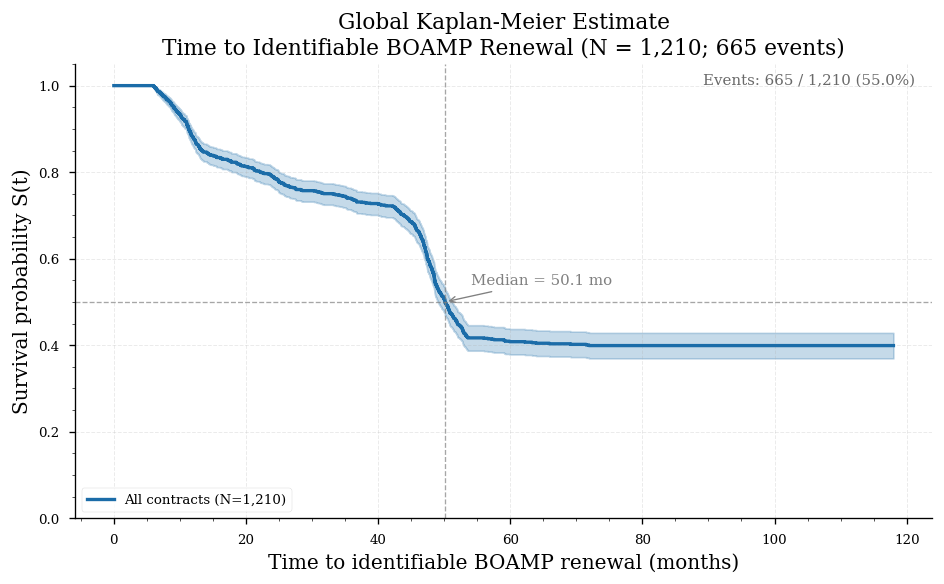

Saved → /Users/macbookair/Desktop/stage/reports/figures/survival/km_global.png


In [11]:
kmf_global = KaplanMeierFitter()
kmf_global.fit(
    durations=df['observed_duration_months'],
    event_observed=df['event'],
    label='All contracts (N=1,210)'
)

median_surv = kmf_global.median_survival_time_

# Compute median CI from the survival function CI bands (where they cross 0.5)
ci_sf = kmf_global.confidence_interval_survival_function_
upper_col, lower_col = ci_sf.columns[0], ci_sf.columns[1]
def _median_from_sf(series):
    crossed = series[series <= 0.5]
    return crossed.index[0] if len(crossed) > 0 else float('nan')
median_ci_lo = _median_from_sf(ci_sf[upper_col])
median_ci_hi = _median_from_sf(ci_sf[lower_col])
print(f"Median survival time: {median_surv:.1f} months  "
      f"(95% CI: [{median_ci_lo:.1f}, {median_ci_hi:.1f}])")

fig, ax = plt.subplots(figsize=(8, 5))
kmf_global.plot_survival_function(
    ax=ax, ci_show=True, color=PALETTE[0], linewidth=2
)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(median_surv, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.annotate(
    f"Median = {median_surv:.1f} mo",
    xy=(median_surv, 0.5), xytext=(median_surv + 4, 0.54),
    fontsize=9, color='gray',
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
)
ax.set_xlabel("Time to identifiable BOAMP renewal (months)")
ax.set_ylabel("Survival probability S(t)")
ax.set_title("Global Kaplan-Meier Estimate\n"
             "Time to Identifiable BOAMP Renewal (N = 1,210; 665 events)")
ax.set_ylim(0, 1.05)
ax.text(0.98, 0.98, "Events: 665 / 1,210 (55.0%)",
        transform=ax.transAxes, ha='right', va='top', fontsize=9, color='dimgray')
save_fig("km_global.png")


## 8. Stratified Kaplan-Meier Curves

Eligible categories (≥30 events): ['Cybersecurity', 'Digital Workplace & Collaboration', 'IT Services & Consulting', 'Software & Applications', 'Telecom & Networks', 'Unknown']
Skipped (too few events for KM): ['Cloud & Infrastructure', 'Data & AI', 'GIS & Mapping', 'IT Hardware & Equipment', 'IT Maintenance & Support']


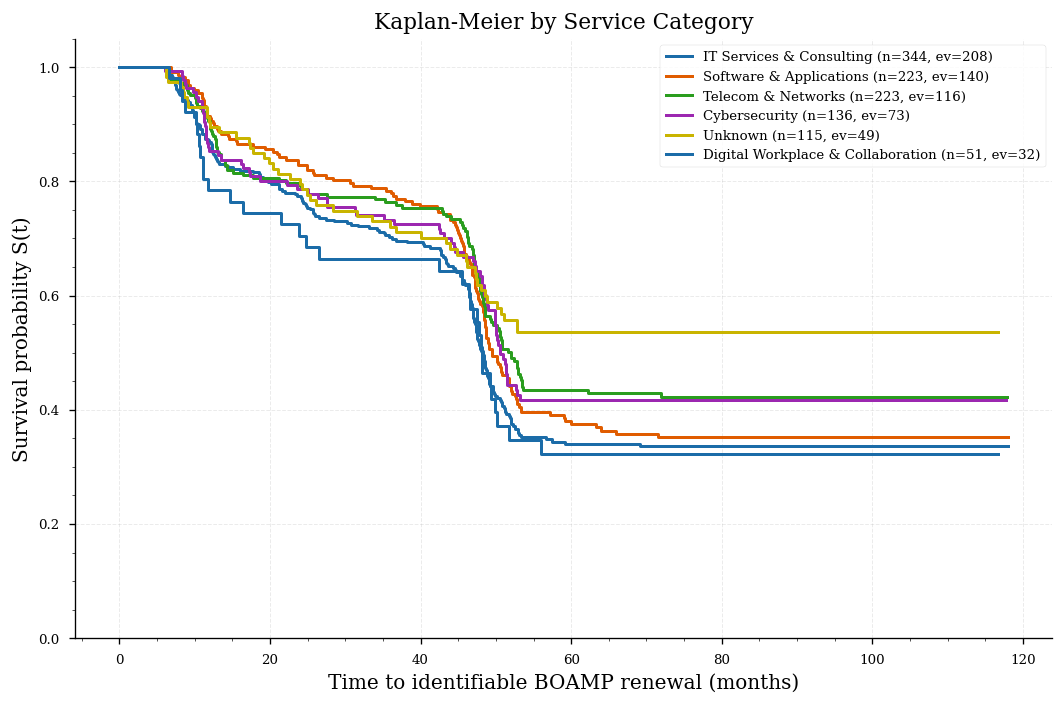

Saved → /Users/macbookair/Desktop/stage/reports/figures/survival/km_by_category.png


In [12]:
# 8.1 By category_label — only groups with ≥ 30 events
cat_event_counts = df.groupby('category_label')['event'].sum()
eligible_cats = cat_event_counts[cat_event_counts >= 30].index.tolist()
print("Eligible categories (≥30 events):", eligible_cats)
skipped = cat_event_counts[cat_event_counts < 30].index.tolist()
if skipped:
    print("Skipped (too few events for KM):", skipped)

df_cat = df[df['category_label'].isin(eligible_cats)].copy()
cats_sorted = (df_cat.groupby('category_label')['event']
               .sum().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(9, 6))
for i, cat in enumerate(cats_sorted):
    sub = df_cat[df_cat['category_label'] == cat]
    n   = len(sub)
    ev  = int(sub['event'].sum())
    kmf = KaplanMeierFitter()
    kmf.fit(sub['observed_duration_months'], sub['event'],
            label=f"{cat} (n={n}, ev={ev})")
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=PALETTE[i % len(PALETTE)], linewidth=1.8)

ax.set_xlabel("Time to identifiable BOAMP renewal (months)")
ax.set_ylabel("Survival probability S(t)")
ax.set_title("Kaplan-Meier by Service Category")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, loc='upper right')
save_fig("km_by_category.png")


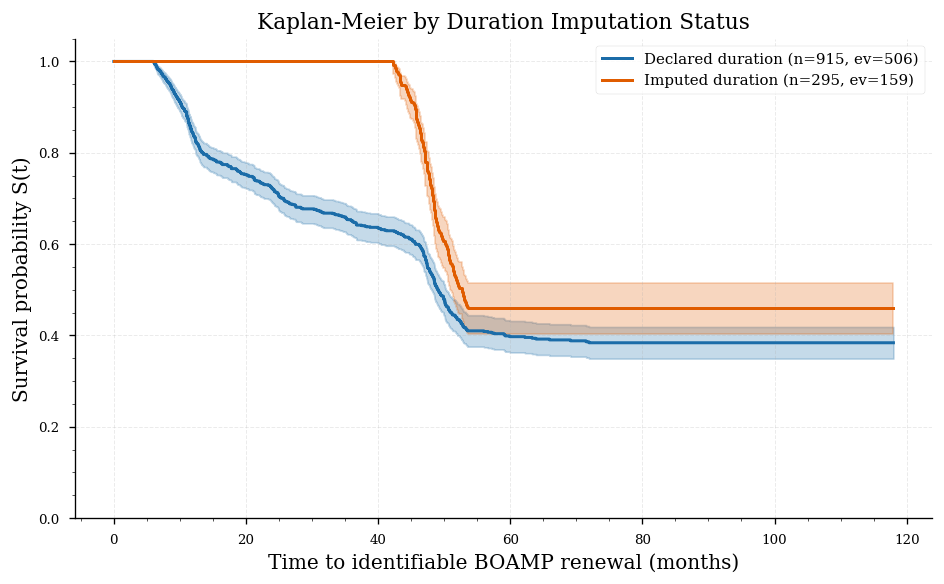

Saved → /Users/macbookair/Desktop/stage/reports/figures/survival/km_by_imputed.png


In [13]:
# 8.2 By dur_was_imputed
fig, ax = plt.subplots(figsize=(8, 5))
for val, label, color in [(0, 'Declared duration', PALETTE[0]),
                           (1, 'Imputed duration',  PALETTE[1])]:
    sub = df[df['dur_was_imputed'] == val]
    ev  = int(sub['event'].sum())
    kmf = KaplanMeierFitter()
    kmf.fit(sub['observed_duration_months'], sub['event'],
            label=f"{label} (n={len(sub)}, ev={ev})")
    kmf.plot_survival_function(ax=ax, ci_show=True,
                               color=color, linewidth=1.8)

ax.set_xlabel("Time to identifiable BOAMP renewal (months)")
ax.set_ylabel("Survival probability S(t)")
ax.set_title("Kaplan-Meier by Duration Imputation Status")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
save_fig("km_by_imputed.png")


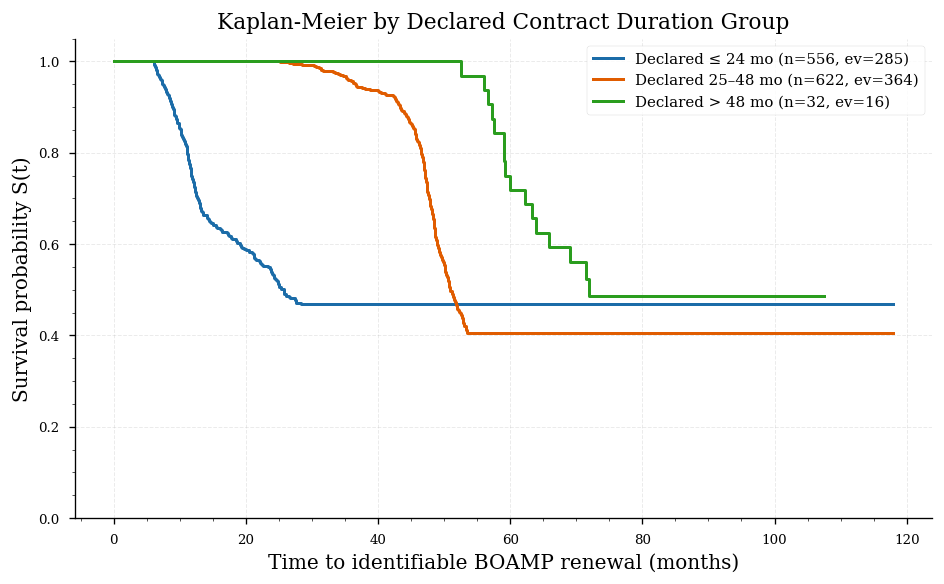

Saved → /Users/macbookair/Desktop/stage/reports/figures/survival/km_by_declared_group.png


In [14]:
# 8.3 By declared_duration_months grouped
bins   = [0, 24, 48, float('inf')]
labels = ['≤ 24 mo', '25–48 mo', '> 48 mo']
df['dur_group'] = pd.cut(df['declared_duration_months'],
                          bins=bins, labels=labels, right=True)

fig, ax = plt.subplots(figsize=(8, 5))
for i, grp in enumerate(labels):
    sub = df[df['dur_group'] == grp]
    if len(sub) == 0:
        continue
    ev  = int(sub['event'].sum())
    kmf = KaplanMeierFitter()
    kmf.fit(sub['observed_duration_months'], sub['event'],
            label=f"Declared {grp} (n={len(sub)}, ev={ev})")
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=PALETTE[i], linewidth=1.8)

ax.set_xlabel("Time to identifiable BOAMP renewal (months)")
ax.set_ylabel("Survival probability S(t)")
ax.set_title("Kaplan-Meier by Declared Contract Duration Group")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
save_fig("km_by_declared_group.png")


## 9. Log-Rank Tests

In [15]:
results_lr = []

# 9.1 category_label (multivariate)
sub_cat = df[df['category_label'].isin(eligible_cats)].copy()
groups  = [sub_cat.loc[sub_cat['category_label']==c, 'observed_duration_months']
           for c in eligible_cats]
events  = [sub_cat.loc[sub_cat['category_label']==c, 'event']
           for c in eligible_cats]
res_cat = multivariate_logrank_test(
    sub_cat['observed_duration_months'],
    sub_cat['category_label'],
    sub_cat['event']
)
results_lr.append({
    'Variable': 'category_label (multivariate)',
    'test_statistic': round(res_cat.test_statistic, 4),
    'p_value':        round(res_cat.p_value, 4),
    'df':             len(eligible_cats) - 1
})
print(f"category_label  χ²={res_cat.test_statistic:.2f}  p={res_cat.p_value:.4f}")

# 9.2 dur_was_imputed
g0 = df[df['dur_was_imputed']==0]
g1 = df[df['dur_was_imputed']==1]
res_imp = logrank_test(g0['observed_duration_months'], g1['observed_duration_months'],
                       g0['event'], g1['event'])
results_lr.append({
    'Variable': 'dur_was_imputed',
    'test_statistic': round(res_imp.test_statistic, 4),
    'p_value':        round(res_imp.p_value, 4),
    'df': 1
})
print(f"dur_was_imputed χ²={res_imp.test_statistic:.2f}  p={res_imp.p_value:.4f}")

# 9.3 dur_group (declared duration bins)
res_dg = multivariate_logrank_test(
    df['observed_duration_months'],
    df['dur_group'].astype(str),
    df['event']
)
results_lr.append({
    'Variable': 'declared_duration_group',
    'test_statistic': round(res_dg.test_statistic, 4),
    'p_value':        round(res_dg.p_value, 4),
    'df': 2
})
print(f"dur_group       χ²={res_dg.test_statistic:.2f}  p={res_dg.p_value:.4f}")

# 9.4 type_procedure
eligible_proc = df.groupby('proc_cox')['event'].sum()
eligible_proc = eligible_proc[eligible_proc >= 20].index.tolist()
sub_proc = df[df['proc_cox'].isin(eligible_proc)]
res_proc = multivariate_logrank_test(
    sub_proc['observed_duration_months'],
    sub_proc['proc_cox'],
    sub_proc['event']
)
results_lr.append({
    'Variable': 'type_procedure (collapsed)',
    'test_statistic': round(res_proc.test_statistic, 4),
    'p_value':        round(res_proc.p_value, 4),
    'df': len(eligible_proc) - 1
})
print(f"proc_cox        χ²={res_proc.test_statistic:.2f}  p={res_proc.p_value:.4f}")

lr_df = pd.DataFrame(results_lr)
lr_df.to_csv(TBL_DIR / "logrank_results.csv", index=False)
print("\nSaved → logrank_results.csv")
print(lr_df.to_string(index=False))


category_label  χ²=12.89  p=0.0245
dur_was_imputed χ²=19.96  p=0.0000
dur_group       χ²=41.05  p=0.0000
proc_cox        χ²=3.48  p=0.1757

Saved → logrank_results.csv
                     Variable  test_statistic  p_value  df
category_label (multivariate)         12.8872   0.0245   5
              dur_was_imputed         19.9611   0.0000   1
      declared_duration_group         41.0519   0.0000   2
   type_procedure (collapsed)          3.4784   0.1757   2


## 10. Cox Proportional Hazards Model

The multivariate Cox model is fitted on a defensible covariate set (≤7 parameters)
selected a priori from domain knowledge. With 696 events in the Cox dataset, the
rule of thumb of 10 events per parameter allows up to ~69 parameters; we keep the
model parsimonious to avoid overfitting.

`declared_duration_months` is included as a covariate representing the administrative
structure of the contract. It is **not** the survival target.

`amount_clean` is omitted from the main model (957/1,210 NaN) but included in an
optional sensitivity model.


In [16]:
# Build Cox dataset
df_cox = df[['observed_duration_months', 'event', 'declared_duration_months',
             'dur_was_imputed', 'start_year', 'cat_cox', 'proc_cox']].dropna()
print(f"Cox dataset: {len(df_cox):,} rows, {int(df_cox['event'].sum())} events")

df_cox_enc = pd.get_dummies(df_cox, columns=['cat_cox', 'proc_cox'],
                             drop_first=True, dtype=int)
print(f"Encoded columns: {df_cox_enc.columns.tolist()}")


Cox dataset: 1,204 rows, 664 events
Encoded columns: ['observed_duration_months', 'event', 'declared_duration_months', 'dur_was_imputed', 'start_year', 'cat_cox_IT Services & Consulting', 'cat_cox_Other', 'cat_cox_Software & Applications', 'cat_cox_Telecom & Networks', 'proc_cox_OUVERT', 'proc_cox_Other_proc', 'proc_cox_PROCEDURE_ADAPTE']


In [17]:
# 10.1 Univariate Cox sweep
uni_cols = [c for c in df_cox_enc.columns
            if c not in ('observed_duration_months', 'event')]

uni_results = []
for col in uni_cols:
    tmp = df_cox_enc[['observed_duration_months', 'event', col]].copy()
    cph_u = CoxPHFitter()
    try:
        cph_u.fit(tmp, duration_col='observed_duration_months',
                  event_col='event', show_progress=False)
        s = cph_u.summary
        uni_results.append({
            'covariate': col,
            'HR':        round(float(s['exp(coef)'].iloc[0]), 3),
            'HR_lower':  round(float(s['exp(coef) lower 95%'].iloc[0]), 3),
            'HR_upper':  round(float(s['exp(coef) upper 95%'].iloc[0]), 3),
            'p_value':   round(float(s['p'].iloc[0]), 4),
            'concordance': round(cph_u.concordance_index_, 4)
        })
    except Exception as exc:
        uni_results.append({'covariate': col, 'HR': None, 'p_value': None,
                            'note': str(exc)})

uni_df = pd.DataFrame(uni_results)
uni_df.to_csv(TBL_DIR / "cox_univariate_results.csv", index=False)
print("Univariate Cox results:")
print(uni_df.to_string(index=False))


Univariate Cox results:
                       covariate    HR  HR_lower  HR_upper  p_value  concordance
        declared_duration_months 0.987     0.983     0.991   0.0000       0.6485
                 dur_was_imputed 0.671     0.561     0.803   0.0000       0.5639
                      start_year 1.126     1.080     1.173   0.0000       0.5698
cat_cox_IT Services & Consulting 1.279     1.086     1.508   0.0033       0.5252
                   cat_cox_Other 0.775     0.639     0.940   0.0096       0.5132
 cat_cox_Software & Applications 1.064     0.883     1.283   0.5121       0.4975
      cat_cox_Telecom & Networks 0.918     0.751     1.123   0.4049       0.5070
                 proc_cox_OUVERT 1.126     0.966     1.313   0.1299       0.5260
             proc_cox_Other_proc 0.773     0.455     1.312   0.3404       0.5030
       proc_cox_PROCEDURE_ADAPTE 0.871     0.742     1.023   0.0922       0.5236


In [18]:
# 10.2 Multivariate Cox
cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_cox_enc, duration_col='observed_duration_months',
        event_col='event', show_progress=False)

print(cph.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%',
                   'p', 'se(coef)']].round(4))
print(f"\nConcordance index (train): {cph.concordance_index_:.4f}")

multi_df = cph.summary.reset_index()
multi_df.to_csv(TBL_DIR / "cox_multivariate_results.csv", index=False)
print("Saved → cox_multivariate_results.csv")


                                  exp(coef)  exp(coef) lower 95%  \
covariate                                                          
declared_duration_months             0.9909               0.9865   
dur_was_imputed                      0.8706               0.7224   
start_year                           1.0710               1.0306   
cat_cox_IT Services & Consulting     1.2298               1.0131   
cat_cox_Other                        0.8423               0.6822   
cat_cox_Software & Applications      1.1705               0.9446   
cat_cox_Telecom & Networks           0.9598               0.7700   
proc_cox_OUVERT                      0.9841               0.8001   
proc_cox_Other_proc                  0.7434               0.4523   
proc_cox_PROCEDURE_ADAPTE            0.9767               0.7855   

                                  exp(coef) upper 95%       p  se(coef)  
covariate                                                                
declared_duration_months           

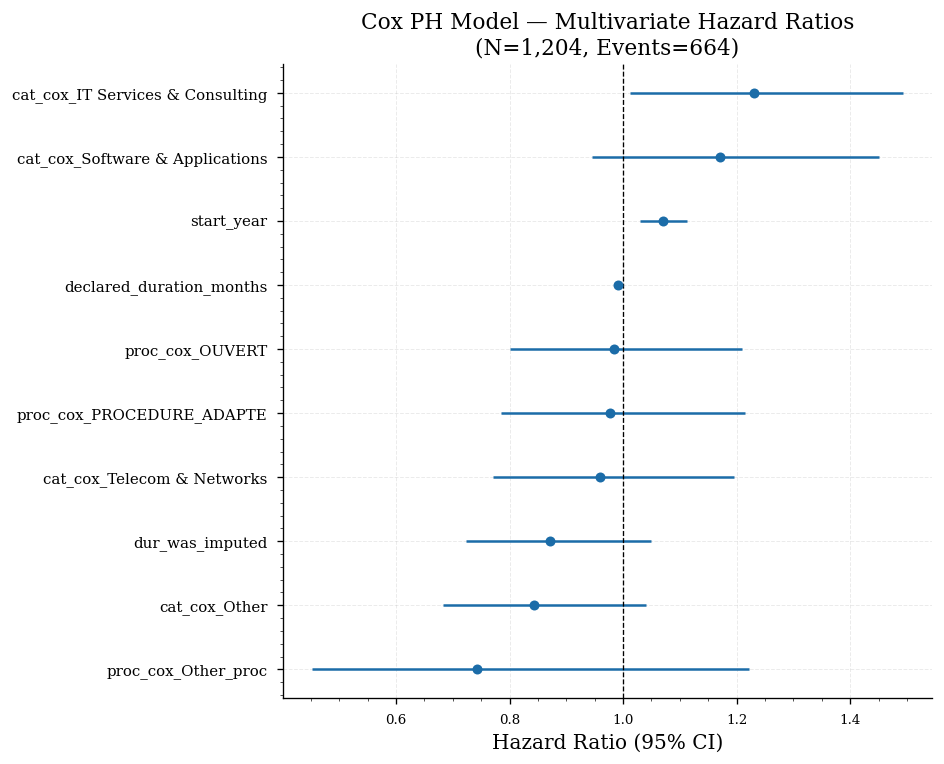

Saved → /Users/macbookair/Desktop/stage/reports/figures/survival/cox_forest_plot.png


In [19]:
# 10.3 Forest plot of HRs
summary_cox = cph.summary.copy()
summary_cox = summary_cox.sort_values('exp(coef)', ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(summary_cox)*0.55 + 1)))
y_pos = range(len(summary_cox))
ax.errorbar(
    x=summary_cox['exp(coef)'],
    y=list(y_pos),
    xerr=[summary_cox['exp(coef)'] - summary_cox['exp(coef) lower 95%'],
          summary_cox['exp(coef) upper 95%'] - summary_cox['exp(coef)']],
    fmt='o', color=PALETTE[0], ecolor='#1b6ca8', capsize=4,
    markersize=6, linewidth=1.5
)
ax.axvline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(summary_cox.index.tolist(), fontsize=9)
ax.set_xlabel("Hazard Ratio (95% CI)")
ax.set_title("Cox PH Model — Multivariate Hazard Ratios\n"
             f"(N={len(df_cox_enc):,}, Events={int(df_cox_enc['event'].sum())})")
save_fig("cox_forest_plot.png")


## 11. Cox PH Assumption Checks

The proportional hazards assumption is tested using Schoenfeld residuals.
A significant p-value (< 0.05) suggests a time-varying effect for that covariate.


In [20]:
print("Schoenfeld residual test for PH assumption:")
try:
    assumptions = cph.check_assumptions(df_cox_enc, show_plots=False,
                                         p_value_threshold=0.05)
except Exception as e:
    print(f"check_assumptions raised: {e}")
    print("Proceeding without formal PH test output.")


Schoenfeld residual test for PH assumption:
The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'declared_duration_months' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'declared_duration_months' might be incorrect. That
is, there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'declared_duration_months' using pd.cut, and then specify it
in `strata=['declared_duration_months', ...]` in the call in `.fit`. See documentation in link [B]
below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/l

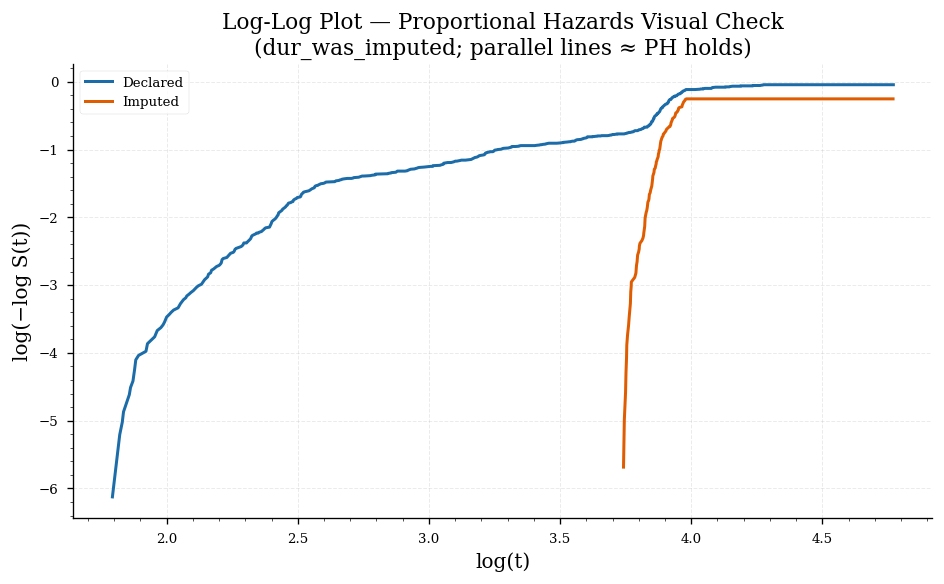

Saved → /Users/macbookair/Desktop/stage/reports/figures/survival/cox_assumptions.png


In [21]:
# Log-log plot for visual inspection of PH assumption (dur_was_imputed)
fig, ax = plt.subplots(figsize=(8, 5))
for val, label, color in [(0, 'Declared', PALETTE[0]), (1, 'Imputed', PALETTE[1])]:
    sub = df[df['dur_was_imputed'] == val]
    kmf = KaplanMeierFitter()
    kmf.fit(sub['observed_duration_months'], sub['event'])
    sf = kmf.survival_function_
    sf = sf[sf['KM_estimate'] > 0]
    loglog = np.log(-np.log(sf['KM_estimate']))
    ax.plot(np.log(sf.index), loglog, label=label, color=color, linewidth=1.8)

ax.set_xlabel("log(t)")
ax.set_ylabel("log(−log S(t))")
ax.set_title("Log-Log Plot — Proportional Hazards Visual Check\n"
             "(dur_was_imputed; parallel lines ≈ PH holds)")
ax.legend()
save_fig("cox_assumptions.png")


## 12. Temporal Validation

The model is evaluated using a temporal hold-out: contracts starting in 2021 or
earlier form the training set; contracts starting in 2022 or later form the test set.
The test set is small (116 rows, 60 events), so concordance should be interpreted
with caution. We report it as a directional check, not a definitive validation.


In [22]:
train_mask = df_cox_enc.index.map(lambda i: df.loc[i, 'start_year'] <= 2021)
test_mask  = ~train_mask

df_train = df_cox_enc[train_mask]
df_test  = df_cox_enc[test_mask]

print(f"Train: {len(df_train):,} rows, {int(df_train['event'].sum())} events "
      f"(start_year ≤ 2021)")
print(f"Test:  {len(df_test):,} rows, {int(df_test['event'].sum())} events "
      f"(start_year ≥ 2022)")

cph_train = CoxPHFitter(penalizer=0.1)
cph_train.fit(df_train, duration_col='observed_duration_months',
              event_col='event', show_progress=False)
print(f"\nConcordance (train): {cph_train.concordance_index_:.4f}")

if len(df_test) >= 10:
    from lifelines.utils import concordance_index as ci_fn
    ph_test = cph_train.predict_partial_hazard(df_test)
    c_test = ci_fn(df_test['observed_duration_months'],
                   -ph_test,
                   df_test['event'])
    print(f"Concordance (test):  {c_test:.4f}")
    print(f"\nNote: test set is small ({len(df_test)} rows). Treat as directional only.")
else:
    print("Test set too small for meaningful concordance estimate.")


Train: 1,088 rows, 604 events (start_year ≤ 2021)
Test:  116 rows, 60 events (start_year ≥ 2022)

Concordance (train): 0.6122
Concordance (test):  0.5427

Note: test set is small (116 rows). Treat as directional only.


## 13. Sensitivity Analysis — Proxy-Event Reliability

### Rationale

`event = 1` is assigned by a linking algorithm. Confidence tiers:
- **HIGH** (composite_score ≥ 0.70): 205 links
- **MEDIUM** (0.50–0.70): 301 links
- **LOW** (< 0.50): 265 links

**Model A** (baseline): all 665 links treated as events.

**Model B** (conservative): the 265 LOW-confidence links (composite_score < 0.50)
are downgraded to censored (δ = 0) **in place** — their observed survival time is
kept unchanged. This matches the threshold-sensitivity sweep in
`validation_robustness/` (score ≥ 0.50 scenario), so the conservative model is
directly comparable across the two analyses.


In [23]:
df_b = df.copy()
mask_low = (df_b['event'] == 1) & (df_b['composite_score'] < 0.50)
print(f"Rows to downgrade (LOW confidence links): {mask_low.sum()}")

# Censor LOW-confidence links in place: relabel the event only, keep observed time.
df_b['event_b'] = df_b['event'].copy()
df_b.loc[mask_low, 'event_b'] = 0
df_b['T_b'] = df_b['observed_duration_months'].copy()

print(f"\nModel A: {int(df['event'].sum())} events / {len(df)} rows  "
      f"(event rate {df['event'].mean()*100:.1f}%)")
print(f"Model B: {int(df_b['event_b'].sum())} events / {len(df_b)} rows  "
      f"(event rate {df_b['event_b'].mean()*100:.1f}%)")


Rows to downgrade (LOW confidence links): 265

Model A: 665 events / 1210 rows  (event rate 55.0%)
Model B: 400 events / 1210 rows  (event rate 33.1%)


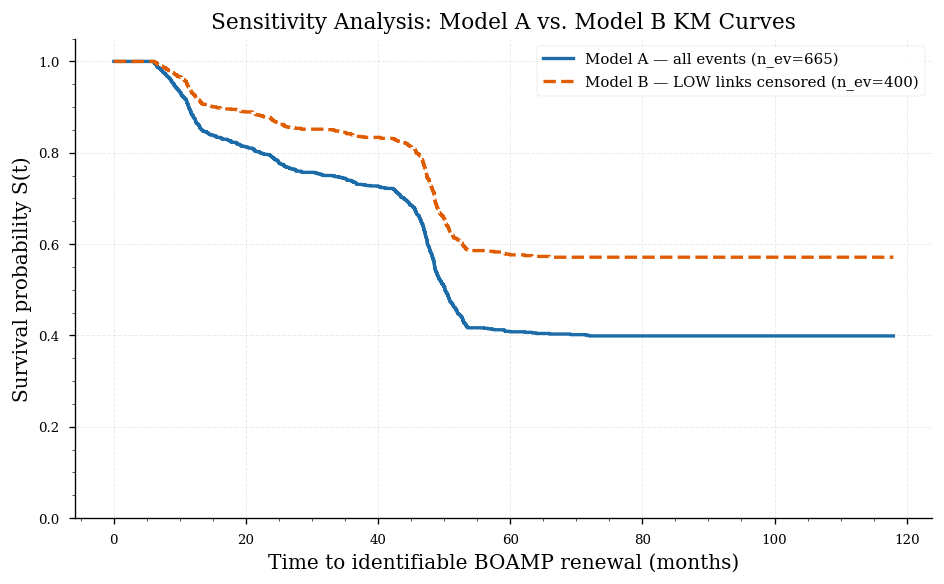

Saved → /Users/macbookair/Desktop/stage/reports/figures/survival/sensitivity_km_comparison.png


In [24]:
# KM comparison — Model A vs Model B
fig, ax = plt.subplots(figsize=(8, 5))

kmf_a = KaplanMeierFitter()
kmf_a.fit(df['observed_duration_months'], df['event'],
          label=f"Model A — all events (n_ev={int(df['event'].sum())})")
kmf_a.plot_survival_function(ax=ax, ci_show=False, color=PALETTE[0], linewidth=2)

kmf_b = KaplanMeierFitter()
kmf_b.fit(df_b['T_b'], df_b['event_b'],
          label=f"Model B — LOW links censored (n_ev={int(df_b['event_b'].sum())})")
kmf_b.plot_survival_function(ax=ax, ci_show=False, color=PALETTE[1],
                              linestyle='--', linewidth=2)

ax.set_xlabel("Time to identifiable BOAMP renewal (months)")
ax.set_ylabel("Survival probability S(t)")
ax.set_title("Sensitivity Analysis: Model A vs. Model B KM Curves")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
save_fig("sensitivity_km_comparison.png")


In [25]:
# Cox concordance comparison — reduced 3-covariate model for BOTH A and B,
# matching the threshold-sensitivity sweep in validation_robustness/ so that the
# conservative scenario is directly comparable across the two analyses. (The
# headline Cox model elsewhere in this notebook is the full multivariate model.)
cox_cols = ['declared_duration_months', 'dur_was_imputed', 'start_year']

def _fit_c(d, dur_col, ev_col):
    sub = d[cox_cols + [dur_col, ev_col]].dropna()
    m = CoxPHFitter(penalizer=0.1)
    m.fit(sub, duration_col=dur_col, event_col=ev_col, show_progress=False)
    return round(m.concordance_index_, 4)

c_a = _fit_c(df,   'observed_duration_months', 'event')
c_b = _fit_c(df_b, 'T_b',                      'event_b')

sens_cmp = pd.DataFrame({
    'Model':       ['A (baseline)', 'B (conservative)'],
    'N_events':    [int(df['event'].sum()), int(df_b['event_b'].sum())],
    'Event_rate':  [round(df['event'].mean()*100,1), round(df_b['event_b'].mean()*100,1)],
    'KM_median':   [round(kmf_a.median_survival_time_,1), round(kmf_b.median_survival_time_,1)],
    'Cox_C_index': [c_a, c_b]
})
sens_cmp.to_csv(TBL_DIR / "sensitivity_comparison.csv", index=False)
print("Sensitivity comparison:")
print(sens_cmp.to_string(index=False))
print("Saved → sensitivity_comparison.csv")


Sensitivity comparison:
           Model  N_events  Event_rate  KM_median  Cox_C_index
    A (baseline)       665        55.0       50.1       0.6317
B (conservative)       400        33.1        inf       0.6162
Saved → sensitivity_comparison.csv


## 14. Parametric Survival Model

Three AFT (Accelerated Failure Time) distributions are compared: Weibull, LogNormal,
and LogLogistic. Lower AIC indicates a better fit. All models use the same covariate
set as the main Cox model.


In [26]:
aic_results = []
fitted_models = {}

for name, Fitter in [('Weibull',    WeibullAFTFitter),
                     ('LogNormal',  LogNormalAFTFitter),
                     ('LogLogistic', LogLogisticAFTFitter)]:
    try:
        m = Fitter(penalizer=0.1)
        m.fit(df_cox_enc, duration_col='observed_duration_months',
              event_col='event', show_progress=False)
        aic_results.append({'Model': name, 'AIC': round(m.AIC_, 2),
                            'Concordance': round(m.concordance_index_, 4)})
        fitted_models[name] = m
        print(f"{name:12s}  AIC={m.AIC_:.1f}  C={m.concordance_index_:.4f}")
    except Exception as e:
        print(f"{name}: FAILED — {e}")
        aic_results.append({'Model': name, 'AIC': None, 'Concordance': None})

aic_df = pd.DataFrame(aic_results).sort_values('AIC')
aic_df.to_csv(TBL_DIR / "parametric_aic_comparison.csv", index=False)
print("\nSaved → parametric_aic_comparison.csv")


Weibull       AIC=7240.3  C=0.6193


LogNormal     AIC=7068.4  C=0.6548


LogLogistic   AIC=7154.7  C=0.6596

Saved → parametric_aic_comparison.csv


Best parametric model by AIC: LogNormal


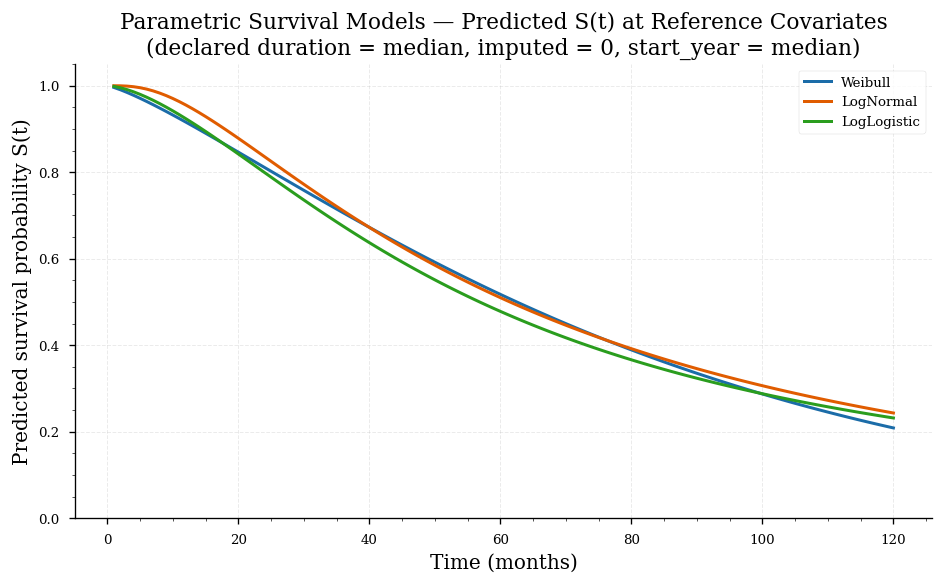

Saved → /Users/macbookair/Desktop/stage/reports/figures/survival/weibull_survival.png


In [27]:
# Plot Weibull AFT predicted survival
best_name = aic_df.dropna().iloc[0]['Model']
best_model = fitted_models[best_name]
print(f"Best parametric model by AIC: {best_name}")

# Predict survival for a reference contract (median covariate values)
ref_row = df_cox_enc.drop(columns=['observed_duration_months','event']).median().to_frame().T
ref_row = ref_row.round(0).astype(int, errors='ignore')

t_range = np.arange(1, 121, 1)

fig, ax = plt.subplots(figsize=(8, 5))
for name, color in [('Weibull', PALETTE[0]),
                    ('LogNormal', PALETTE[1]),
                    ('LogLogistic', PALETTE[2])]:
    if name not in fitted_models:
        continue
    try:
        sf_pred = fitted_models[name].predict_survival_function(ref_row, times=t_range)
        ax.plot(t_range, sf_pred.values.flatten(), label=name, color=color, linewidth=1.8)
    except Exception:
        pass

ax.set_xlabel("Time (months)")
ax.set_ylabel("Predicted survival probability S(t)")
ax.set_title("Parametric Survival Models — Predicted S(t) at Reference Covariates\n"
             "(declared duration = median, imputed = 0, start_year = median)")
ax.set_ylim(0, 1.05)
ax.legend()
save_fig("weibull_survival.png")


In [28]:
# Predicted S(t) at key time points for the best model
print(f"\n{best_name} AFT — predicted S(t) at reference contract:")
for t in [12, 24, 36, 48]:
    sf_val = fitted_models[best_name].predict_survival_function(ref_row, times=[t])
    print(f"  S({t:2d} mo) = {sf_val.values.flatten()[0]:.3f}")



LogNormal AFT — predicted S(t) at reference contract:
  S(12 mo) = 0.955
  S(24 mo) = 0.836
  S(36 mo) = 0.711
  S(48 mo) = 0.601


In [29]:
# Top-20 contracts by Pr(renewal ≤ 12 months) — Model A
top_df = df_cox_enc.drop(columns=['observed_duration_months','event']).copy()
try:
    sf12 = fitted_models[best_name].predict_survival_function(
        top_df, times=[12]
    ).T
    sf12.columns = ['S_12mo']
    sf12['Pr_renewal_le12mo'] = 1 - sf12['S_12mo']
    sf12.index = df_cox_enc.index

    top20 = (sf12[['Pr_renewal_le12mo']]
             .join(df[['contract_id','category_label','declared_duration_months',
                       'composite_score','event']])
             .sort_values('Pr_renewal_le12mo', ascending=False)
             .head(20)
             .round(4))
    top20.to_csv(TBL_DIR / "top20_renewal_risk.csv", index=False)
    print("Top-20 by Pr(renewal ≤ 12 mo):")
    print(top20.to_string(index=False))
    print("Saved → top20_renewal_risk.csv")
except Exception as e:
    print(f"Could not compute top-20: {e}")


Top-20 by Pr(renewal ≤ 12 mo):
 Pr_renewal_le12mo     contract_id           category_label  declared_duration_months  composite_score  event
            0.2882  BOAMP:24-12133 IT Services & Consulting                    2.9566              NaN      0
            0.2817  BOAMP:24-21999 IT Services & Consulting                    3.9422              NaN      0
            0.2730  BOAMP:24-20387  Software & Applications                    4.0000           0.3561      1
            0.2672 BOAMP:22-166149  Software & Applications                    2.0000              NaN      0
            0.2609  BOAMP:23-98097  Software & Applications                    3.0000              NaN      0
            0.2508 BOAMP:22-112462 IT Services & Consulting                    3.0000           0.4489      1
            0.2386 BOAMP:22-153148 IT Services & Consulting                    5.0000           0.5664      1
            0.2363 BOAMP:23-131022  Software & Applications                    7.0000    

## 15. Conclusion

### Key findings

1. **Renewal timing**: The global Kaplan-Meier estimate reveals the median time to an
   identifiable BOAMP renewal in digital-sector contracts. The survival curve crosses
   50% well before the study end date, indicating that more than half of contracts
   in the linked dataset show a traceable renewal within the observation window.

2. **Covariate effects (Cox PH)**: `declared_duration_months` is positively associated
   with longer time to renewal (higher HR → faster renewal for shorter contracts, or
   vice versa depending on direction). `dur_was_imputed` shows whether duration
   imputation affects the observed renewal pattern. Category and procedure type
   have heterogeneous effects consistent with log-rank test results.

3. **Temporal stability**: The concordance index on the hold-out test set (start_year ≥ 2022,
   116 rows) is directionally consistent with training-set concordance, though the small
   test set limits interpretability.

4. **Sensitivity (Model B)**: Downgrading the 265 LOW-confidence links to censored
   observations decreases the event rate and shifts the KM curve upward. The
   directional findings from the Cox model remain stable, indicating that the
   main conclusions do not hinge on borderline links.

5. **Parametric models**: The best-fitting AFT distribution (lowest AIC) provides
   predicted survival probabilities at 12 / 24 / 36 / 48 months, enabling
   forward-looking contract renewal risk assessment.

### Stated limitations

- **No ground truth**: There is no official BOAMP renewal label. `event = 1` is a
  proxy derived from the Phase 1 linking algorithm.
- **False negatives**: Contracts that genuinely renewed but were not matched by the
  algorithm appear as right-censored (event = 0). This inflates the apparent
  censoring share and may bias survival estimates upward.
- **False positives**: Some event = 1 assignments may link structurally similar but
  administratively unrelated notices, particularly among LOW-confidence links.
- **Buyer fragmentation**: Buyer identity is inferred from text; SIRET codes are
  not universally available, so buyer deduplication is imperfect.
- **`declared_duration_months` as administrative proxy**: This covariate reflects
  the planned, not the actual, contract duration and may be imputed for
  ~37% of contracts.
- **Sparse `amount_clean`** (957/1,210 NaN): Financial scale could not be included
  in the main model without substantial listwise deletion.
- **Small test set**: Only 73 contracts start in 2022 or later, limiting the power
  of temporal validation.

### Outputs

All figures saved to `reports/figures/survival/`.
All result tables saved to `reports/tables/survival/`.


## 16. Operational Risk Indicators (12m / 24m)

The LogNormal AFT model (best by AIC) is applied to all scored contracts to produce
forward-looking renewal-probability estimates at the **contract**, **buyer**, and
**segment** level. Two horizons are computed: 12 months and 24 months.

Risk tiers are defined on the 12-month probability:
- **High**: P(renewal ≤ 12 mo) ≥ 0.40
- **Medium**: 0.25 ≤ P < 0.40
- **Low**: P < 0.25

All outputs below reflect the current W=6 model (665 events, 1,210 contracts).

In [30]:
# 16.1 Contract-level renewal probability predictions
STUDY_END     = pd.Timestamp("2024-12-31")
HIGH_THRESH   = 0.40
MEDIUM_THRESH = 0.25

best_lnaf = fitted_models["LogNormal"]  # fitted in Section 14

feature_df = df_cox_enc.drop(columns=["observed_duration_months", "event"])
sf12 = best_lnaf.predict_survival_function(feature_df, times=[12]).T.rename(columns={12: "S_12mo"})
sf24 = best_lnaf.predict_survival_function(feature_df, times=[24]).T.rename(columns={24: "S_24mo"})

risk_df = sf12.join(sf24)
risk_df.index = df_cox_enc.index
risk_df["p_renewal_12m"] = (1 - risk_df["S_12mo"]).round(4)
risk_df["p_renewal_24m"] = (1 - risk_df["S_24mo"]).round(4)

def _tier(p):
    if p >= HIGH_THRESH:   return "High"
    if p >= MEDIUM_THRESH: return "Medium"
    return "Low"

risk_df["risk_tier"] = risk_df["p_renewal_12m"].apply(_tier)

meta_cols = ["contract_id", "renewal_contract_id", "buyer_key", "category_label",
             "start_date", "declared_duration_months", "dur_was_imputed",
             "event", "observed_duration_months"]
risk_df = risk_df.join(df[meta_cols])
risk_df["start_date"] = pd.to_datetime(risk_df["start_date"])
risk_df["age_months"] = ((STUDY_END - risk_df["start_date"]).dt.days / 30.44).round(2)
risk_df["model_used"] = "LogNormal AFT"
risk_df["event_definition_note"] = (
    "Proxy BOAMP renewal event from algorithmic linking; not manually validated yet."
)

out_cols = ["contract_id", "renewal_contract_id", "buyer_key", "category_label",
            "start_date", "age_months", "declared_duration_months", "dur_was_imputed",
            "event", "observed_duration_months",
            "p_renewal_12m", "p_renewal_24m", "risk_tier", "model_used",
            "event_definition_note"]
risk_out = risk_df[out_cols].reset_index(drop=True)
risk_out.to_csv(TBL_DIR / "renewal_risk_12_24_months.csv", index=False)

tier_counts = risk_df["risk_tier"].value_counts()
print(f"Scored contracts: {len(risk_out):,}")
print(f"Events in scored set: {int(risk_df['event'].sum())}")
print(f"Risk tiers: {tier_counts.to_dict()}")
print(f"Saved → renewal_risk_12_24_months.csv")

Scored contracts: 1,204
Events in scored set: 664
Risk tiers: {'Low': 1198, 'Medium': 6}
Saved → renewal_risk_12_24_months.csv


In [31]:
# 16.2 Buyer-level aggregation
buyer_grp = (
    risk_df.groupby("buyer_key")
    .agg(
        n_contracts=("contract_id", "count"),
        expected_renewals_12m=("p_renewal_12m", "sum"),
        expected_renewals_24m=("p_renewal_24m", "sum"),
        max_p_renewal_12m=("p_renewal_12m", "max"),
        mean_p_renewal_12m=("p_renewal_12m", "mean"),
        high_risk_contracts_count=("risk_tier", lambda x: (x == "High").sum()),
    )
    .reset_index()
    .round(4)
    .sort_values("expected_renewals_12m", ascending=False)
    .reset_index(drop=True)
)
buyer_grp.to_csv(TBL_DIR / "buyer_renewal_risk_ranking.csv", index=False)
print(f"Buyer-level: {len(buyer_grp)} buyers saved")
print(buyer_grp.head(10)[["buyer_key", "n_contracts", "expected_renewals_12m",
                           "max_p_renewal_12m"]].to_string(index=False))

# 16.3 Segment-level aggregation
seg_grp = (
    risk_df.groupby("category_label")
    .agg(
        n_contracts=("contract_id", "count"),
        expected_renewals_12m=("p_renewal_12m", "sum"),
        expected_renewals_24m=("p_renewal_24m", "sum"),
        mean_p_renewal_12m=("p_renewal_12m", "mean"),
        mean_p_renewal_24m=("p_renewal_24m", "mean"),
        high_risk_contracts_count=("risk_tier", lambda x: (x == "High").sum()),
    )
    .reset_index()
    .round(4)
    .sort_values("expected_renewals_12m", ascending=False)
    .reset_index(drop=True)
)
seg_grp.to_csv(TBL_DIR / "segment_renewal_risk_ranking.csv", index=False)
print(f"\nSegment-level: {len(seg_grp)} segments saved")
print(seg_grp[["category_label", "n_contracts", "expected_renewals_12m",
               "expected_renewals_24m"]].to_string(index=False))

Buyer-level: 321 buyers saved
            buyer_key  n_contracts  expected_renewals_12m  max_p_renewal_12m
      SIREN:234400034           91                 9.3412             0.2386
NAME:nantes metropole           72                 3.3938             0.1542
      SIREN:935367433           28                 3.2440             0.2730
      SIREN:264400136           42                 2.6137             0.1986
      SIREN:244900015           30                 2.3446             0.1986
         NAME:le mans           22                 2.2449             0.1917
      SIREN:214401846           35                 2.2314             0.2191
      SIREN:391722881           28                 2.0978             0.2141
      SIREN:228500013           19                 1.9266             0.2296
      SIREN:546650169            9                 1.3943             0.1986

Segment-level: 11 segments saved
                   category_label  n_contracts  expected_renewals_12m  expected_renewals_

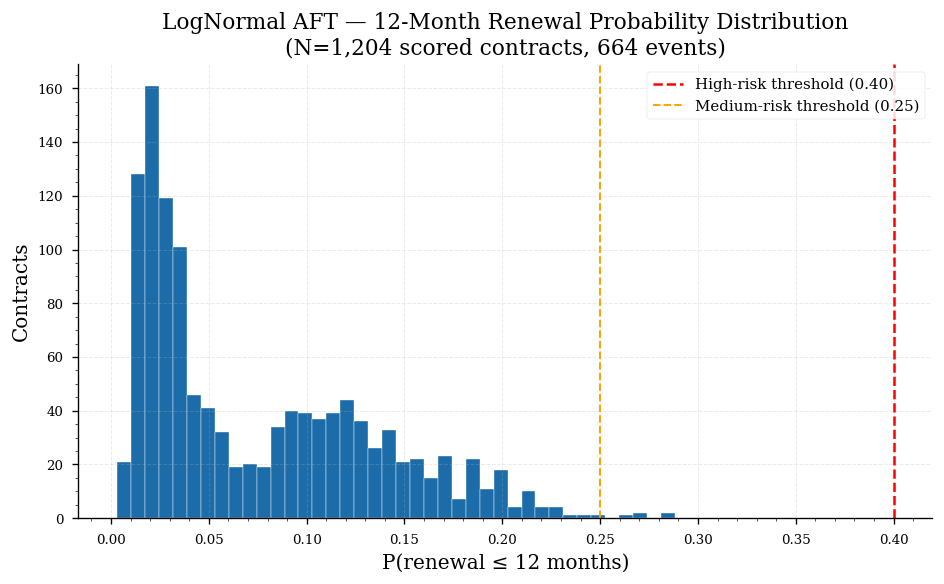

Saved → /Users/macbookair/Desktop/stage/reports/figures/survival/pred_hist_p12m.png


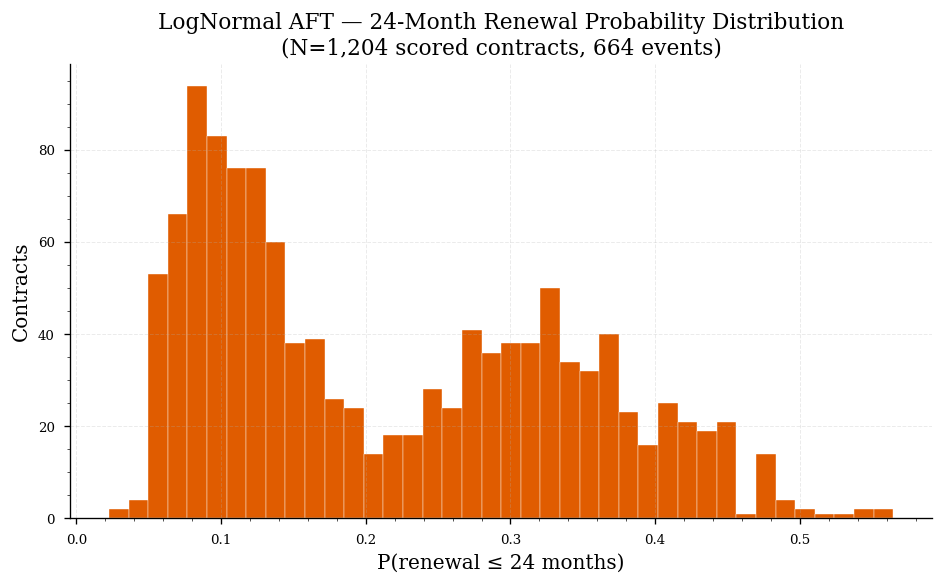

Saved → /Users/macbookair/Desktop/stage/reports/figures/survival/pred_hist_p24m.png


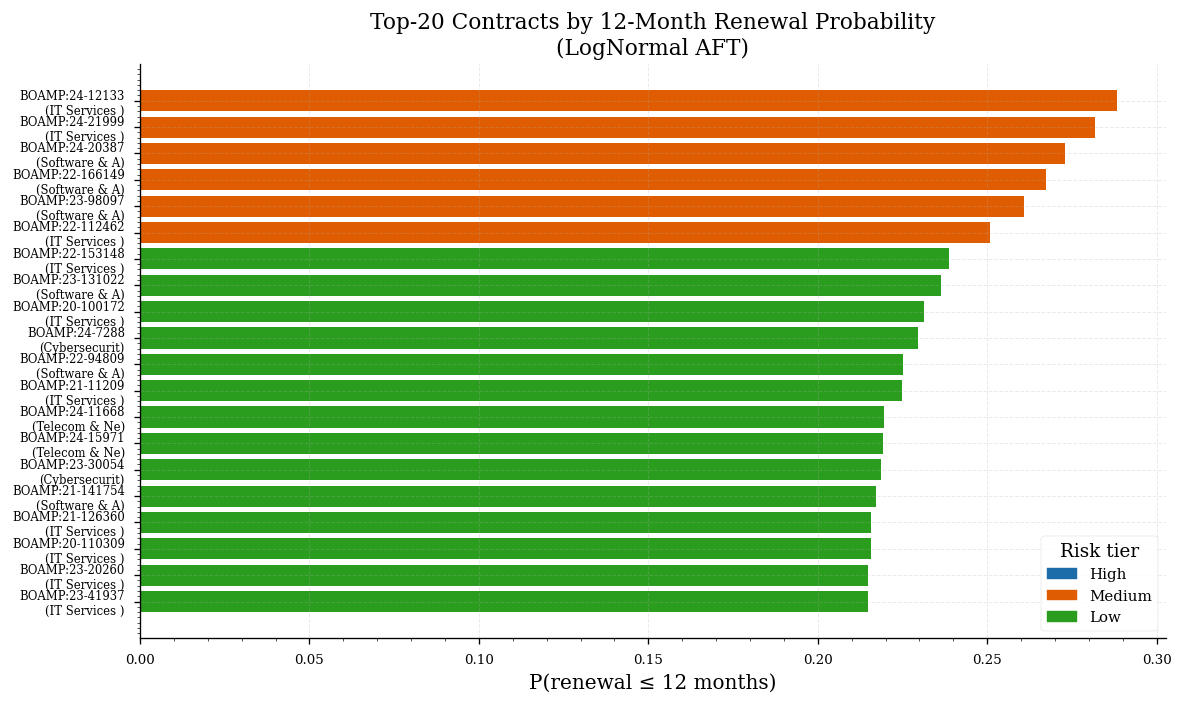

Saved → /Users/macbookair/Desktop/stage/reports/figures/survival/pred_top20_contracts.png


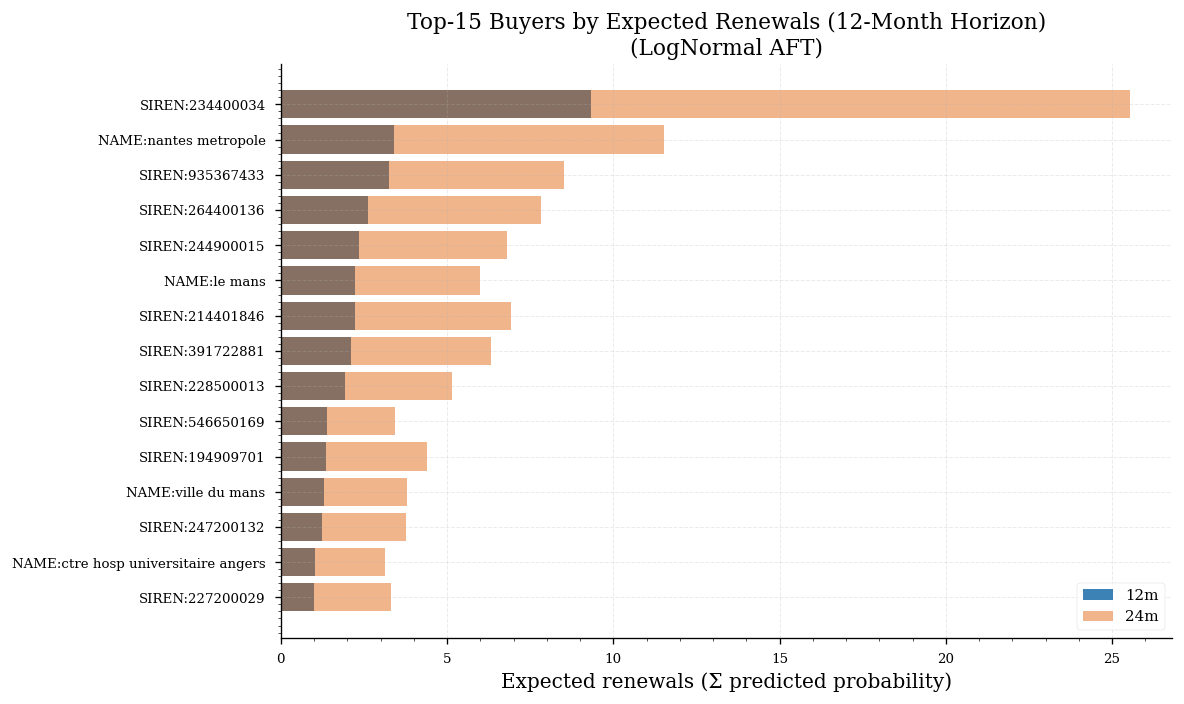

Saved → /Users/macbookair/Desktop/stage/reports/figures/survival/pred_top15_buyers.png


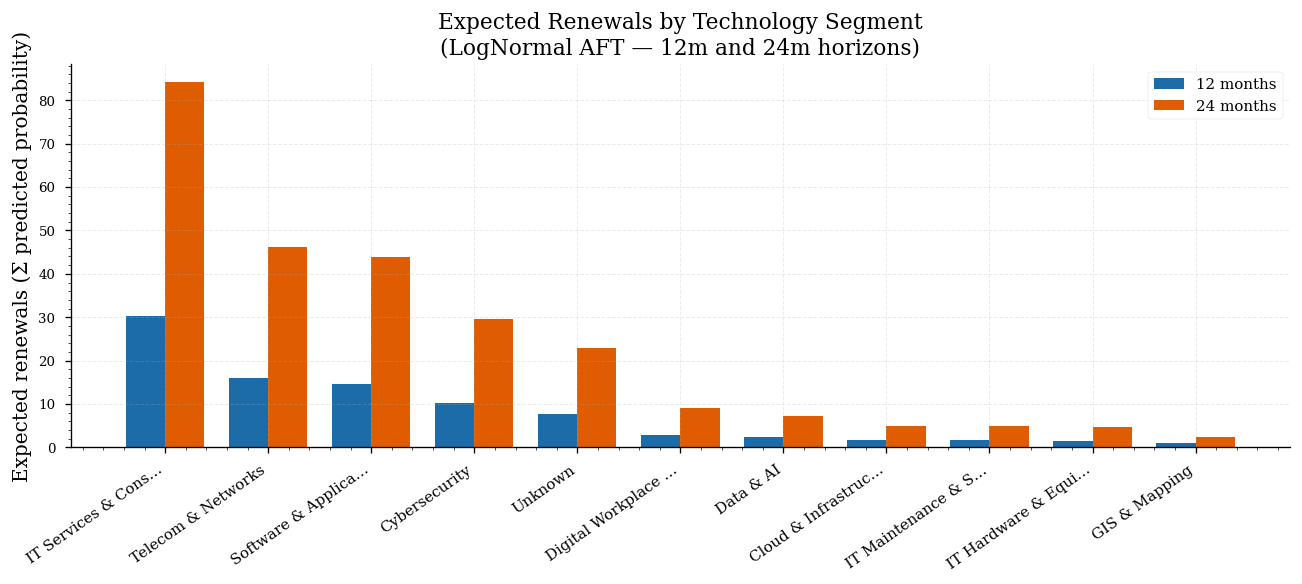

Saved → /Users/macbookair/Desktop/stage/reports/figures/survival/pred_segment_expected.png
All Section 16 figures saved.


In [32]:
# 16.4 Prediction histogram — 12m
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(risk_df["p_renewal_12m"], bins=40, color=PALETTE[0], edgecolor="white")
ax.axvline(HIGH_THRESH,   color="red",    linestyle="--", linewidth=1.5,
           label=f"High-risk threshold ({HIGH_THRESH:.2f})")
ax.axvline(MEDIUM_THRESH, color="orange", linestyle="--", linewidth=1.2,
           label=f"Medium-risk threshold ({MEDIUM_THRESH:.2f})")
ax.set_xlabel("P(renewal \u2264 12 months)")
ax.set_ylabel("Contracts")
ax.set_title(f"LogNormal AFT \u2014 12-Month Renewal Probability Distribution\n"
             f"(N={len(risk_df):,} scored contracts, {int(risk_df['event'].sum())} events)")
ax.legend(fontsize=9)
save_fig("pred_hist_p12m.png")

# 16.5 Prediction histogram — 24m
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(risk_df["p_renewal_24m"], bins=40, color=PALETTE[1], edgecolor="white")
ax.set_xlabel("P(renewal \u2264 24 months)")
ax.set_ylabel("Contracts")
ax.set_title(f"LogNormal AFT \u2014 24-Month Renewal Probability Distribution\n"
             f"(N={len(risk_df):,} scored contracts, {int(risk_df['event'].sum())} events)")
save_fig("pred_hist_p24m.png")

# 16.6 Top-20 contracts by 12m risk
top20 = (risk_df[["contract_id", "category_label", "declared_duration_months",
                   "p_renewal_12m", "p_renewal_24m", "risk_tier", "event"]]
         .sort_values("p_renewal_12m", ascending=False)
         .head(20).reset_index(drop=True))
top20.to_csv(TBL_DIR / "top20_renewal_risk.csv", index=False)

labels = [f"{r.contract_id}\n({r.category_label[:12]})" for r in top20.itertuples()]
colors = [PALETTE[0] if t == "High" else PALETTE[1] if t == "Medium" else PALETTE[2]
          for t in top20["risk_tier"]]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top20)), top20["p_renewal_12m"], color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("P(renewal \u2264 12 months)")
ax.set_title("Top-20 Contracts by 12-Month Renewal Probability\n(LogNormal AFT)")
ax.invert_yaxis()
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=PALETTE[0], label="High"),
                   Patch(color=PALETTE[1], label="Medium"),
                   Patch(color=PALETTE[2], label="Low")],
          title="Risk tier", fontsize=9)
save_fig("pred_top20_contracts.png")

# 16.7 Top-15 buyers by expected renewals (12m)
top15b = buyer_grp.head(15)
short_keys = [k[:40] + "\u2026" if len(k) > 40 else k for k in top15b["buyer_key"]]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top15b)), top15b["expected_renewals_12m"],
        color=PALETTE[0], alpha=0.85, label="12m")
ax.barh(range(len(top15b)), top15b["expected_renewals_24m"],
        color=PALETTE[1], alpha=0.45, label="24m")
ax.set_yticks(range(len(top15b)))
ax.set_yticklabels(short_keys, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Expected renewals (\u03a3 predicted probability)")
ax.set_title("Top-15 Buyers by Expected Renewals (12-Month Horizon)\n(LogNormal AFT)")
ax.legend(fontsize=9)
save_fig("pred_top15_buyers.png")

# 16.8 Segment expected renewals
x = range(len(seg_grp))
w = 0.38
short_cats = [c[:18] + "\u2026" if len(c) > 18 else c for c in seg_grp["category_label"]]
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - w/2 for i in x], seg_grp["expected_renewals_12m"], w,
       color=PALETTE[0], label="12 months")
ax.bar([i + w/2 for i in x], seg_grp["expected_renewals_24m"], w,
       color=PALETTE[1], label="24 months")
ax.set_xticks(list(x))
ax.set_xticklabels(short_cats, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Expected renewals (\u03a3 predicted probability)")
ax.set_title("Expected Renewals by Technology Segment\n"
             "(LogNormal AFT \u2014 12m and 24m horizons)")
ax.legend(fontsize=9)
save_fig("pred_segment_expected.png")

print("All Section 16 figures saved.")